<a href="https://colab.research.google.com/github/MelanyMFM/prueba/blob/main/prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba

In [1]:
import pandas as pd
import numpy as np

In [2]:
itc = pd.read_excel("base_app.xlsx")
cd  = pd.read_excel("base_clave_dinamica.xlsx")
mcd = pd.read_excel("maestro_demografico.xlsx")

- Cada cliente solo tiene una fecha de vinculación al servicio de clave
dinámica.
En caso de que un cliente tenga más de una fecha de vinculación, se debe
tomar la fecha más reciente

In [3]:
cd = cd.sort_values(by='cfechacrea', ascending=False)
cd = cd.drop_duplicates(keep='first', subset='llave_id' )

## Merges

In [4]:
df = pd.merge(cd, mcd, left_on='llave_id', right_on='llave_cli', how='left').drop('llave_cli', axis=1)
df = pd.merge(df, itc, left_on='llave_id', right_on='documento', how='left')

In [5]:
df.head()

,llave_id,ccancrea,cusuario,cfechacrea,cod_of,ctrl_terc,segm,f_vinc,ciudad_of,zona_of,documento,cdgtrn,cdgrpta,vlrtran,anotrn,mestrn,diatrn
0,2361,SVP,WWWR,20201128,NaN,CLIENTE,NEGOCIOS & INDEPEND,20200831,SOACHA - SOACHA,SUROCCIDENTE BOGOTA Y SABANA,2361,538,0,25000.0,2020,11,28
1,2910,SVP,WWWR,20201127,NaN,CLIENTE,PERSONAL,20201125,SANTA MARTA,SIERRA NEVADA,2910,538,0,20000.0,2020,11,28
2,742,SVP,WWWR,20201126,NaN,CLIENTE,PERSONAL,20201126,SABANETA - ANTIOQUIA,SUROESTE Y CHOCO,742,538,0,673000.0,2020,11,28
3,318,SVP,WWWR,20201124,NaN,CLIENTE,PERSONAL,20140910,PEREIRA,EJE CAFETERO SUR,318,438,0,800000.0,2020,11,28
4,47,SVP,WWWR,20201123,NaN,CLIENTE,PERSONAL,20201123,BELLO,NORTE ANTIOQUIA,47,538,0,100000.0,2020,11,28


## Transformaciones

- En un campo aparte, cuando el cdgrpta sea 0 se debe indicar que la
transacción es “Exitosa”, en caso contrario “No exitosa”.

In [6]:
df['ext_trasc'] = np.where(df['cdgrpta'] == 0, 'Exitosa', 'No exitosa')

- Reemplazar los campos anotrn, mestrn y diatrn por el campo fechatrn en
formato numérico AAAAMMDD.

In [7]:
df['anotrn'] = df['anotrn'].astype(str)
df['mestrn'] = df['mestrn'].astype(str)
df['diatrn'] = df['diatrn'].astype(str)
df['fechatrn'] = df['anotrn'] + df['mestrn'] + df['diatrn']

- Adicionar un campo con el nombre del mes de vinculación al servicio de
clave dinámica
(Ejemplo: 2020/12/08 → Diciembre).

In [8]:
def mes(fecha):
  meses = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo',
    4: 'Abril', 5: 'Mayo', 6: 'Junio',
    7: 'Julio', 8: 'Agosto', 9: 'Septiembre',
    10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
  }
  return meses[int(fecha[4:6])]

In [9]:
df['mes_vinc'] = df['cfechacrea'].astype(str).apply(mes)

- Generar un campo con la cantidad de días entre la vinculación del cliente
al servicio de clave dinámica y la transacción.

In [10]:
df['cfechacrea'] = pd.to_datetime(df['cfechacrea'], format='%Y%m%d')
df['fechatrn'] = pd.to_datetime(df['fechatrn'], format='%Y%m%d')
dif_dias = (df['fechatrn'] - df['cfechacrea']).dt.days
df['dias_vinc'] = dif_dias

- Crear una columna a partir del campo cusuario:
Si contiene valores numéricos, se deben extraer estos valores.
Si no contiene valores numéricos, se debe registrar el código 9999.


In [11]:
import re
def num(usuario):
  if re.search(r'\d', usuario):
    return int(re.search(r'\d+', usuario).group(0))
  else:
    return 9999

In [12]:
df['numusuario'] = df['cusuario'].apply(num)

Exportar

In [13]:
df.to_excel("sabana_final.xlsx", index=False)

## Reporte

- Cantidad de transacciones por día, distinguiendo las exitosas de las no
exitosas


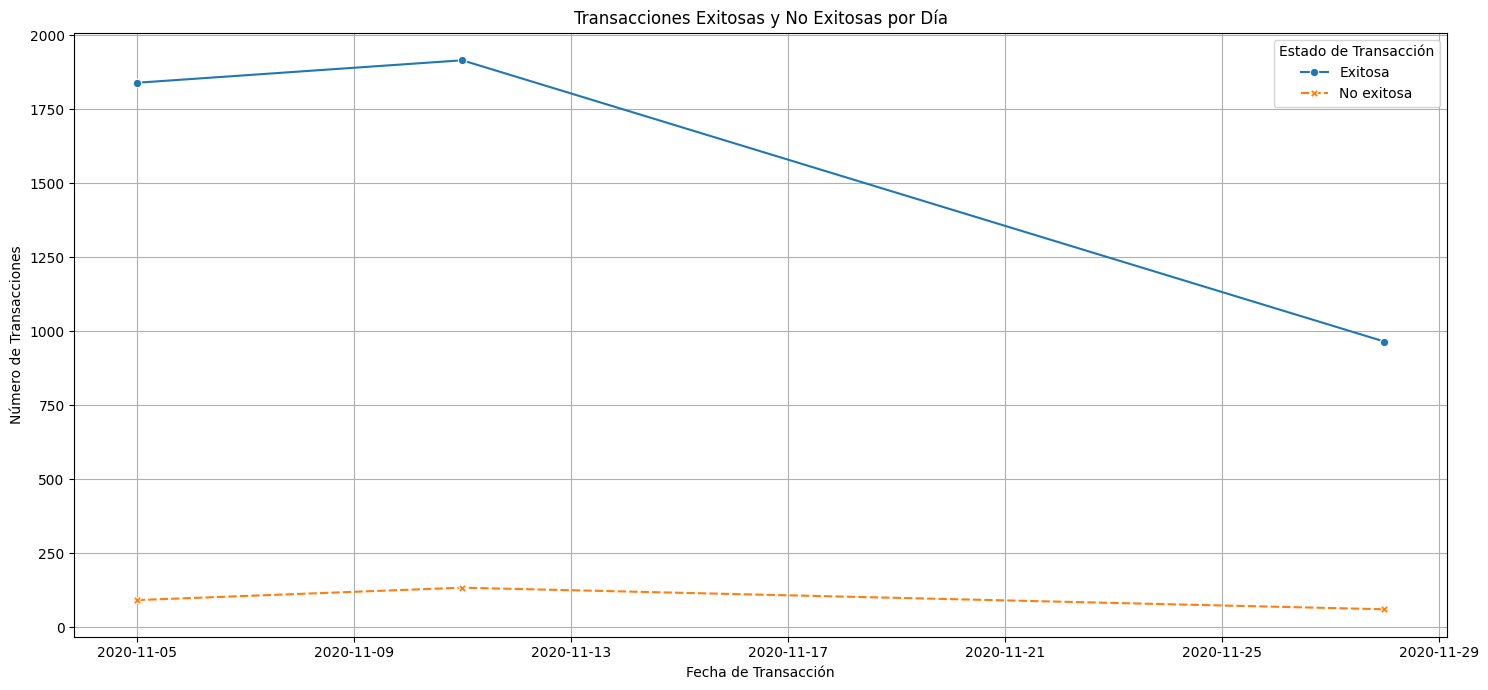

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

transaction_counts = df.groupby(['fechatrn', 'ext_trasc']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 7))
sns.lineplot(data=transaction_counts, markers=True)
plt.title('Transacciones Exitosas y No Exitosas por Día')
plt.xlabel('Fecha de Transacción')
plt.ylabel('Número de Transacciones')
plt.legend(title='Estado de Transacción')
plt.grid(True)
plt.tight_layout()
plt.show()

- Cantidad de transacciones exitosas por segmento.

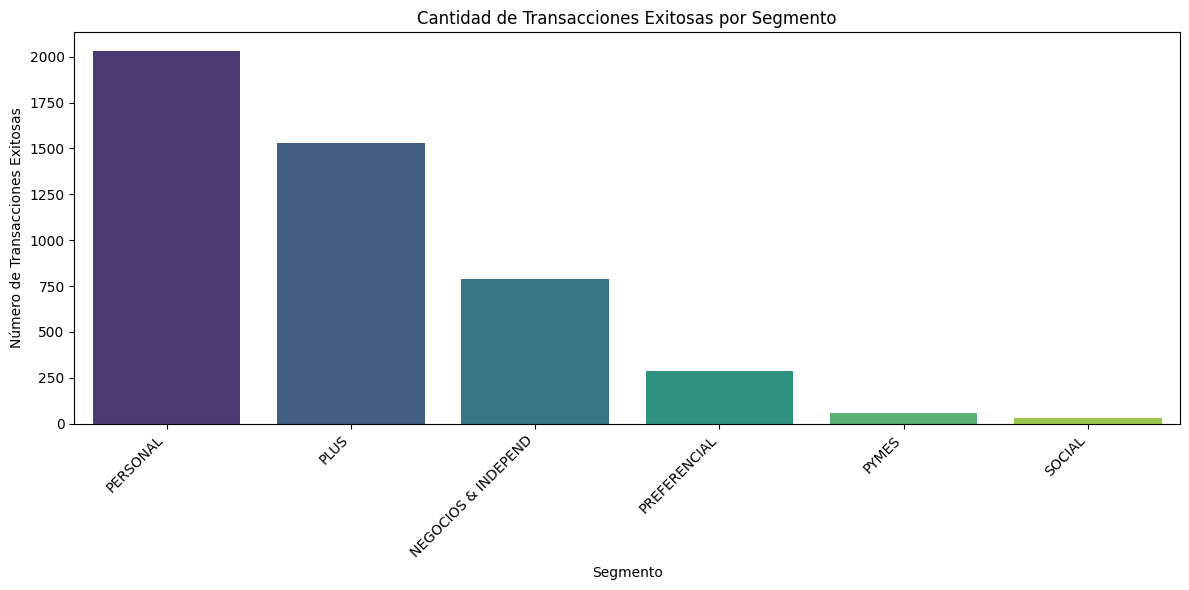

In [16]:
successful_transactions = df[df['ext_trasc'] == 'Exitosa']
transactions_by_segment = successful_transactions.groupby('segm').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=transactions_by_segment.index, y=transactions_by_segment.values, hue=transactions_by_segment.index, palette='viridis', legend=False)
plt.title('Cantidad de Transacciones Exitosas por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Número de Transacciones Exitosas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Top 10 de clientes con mayor monto exitoso en transacciones

In [24]:
top_10_clientes_exitosos = df[df['ext_trasc'] == 'Exitosa'] \
                              .groupby('llave_id')['vlrtran'].sum() \
                              .nlargest(10)
print("Top 10 clientes por monto de transacciones exitosas")
print(top_10_clientes_exitosos)

Top 10 clientes por monto de transacciones exitosas
llave_id
1490    30070000.0
2884    29930000.0
1684    20000000.0
1897    20000000.0
2150    20000000.0
2368    20000000.0
1533    17000000.0
3192    14000000.0
2530    13380000.0
2554    13090000.0
Name: vlrtran, dtype: float64
